In [1]:
from collections import Counter
from intervaltree import IntervalTree, Interval
from matplotlib_venn import venn3, venn2
from matplotlib import pyplot as plt
import pandas as pd
from io import StringIO

def merge_interval(interval_set):
    start = min(map(lambda x: x.begin, interval_set))
    end = max(map(lambda x: x.end, interval_set))
    df = pd.concat(list(map(lambda x: pd.read_json(StringIO(x.data), orient='index').T, interval_set)), ignore_index=True)
    return Interval(start, end, df.to_json())

def build_loci_tree(df_list):
    trees = [IntervalTree() for _ in range(22)]
    for df in df_list:
        df['p'] = df['p'].astype(str)
        for _, row in df.iterrows():
            chrom = row.chr
            tree = trees[chrom-1]
            i = Interval(row.start-125000, row.end+125001, row.to_json()) # If the gap is less than 250k, merge the 2 interval
            o = tree.overlap(row.start-125000, row.end+125001)
            o.add(i)
            n = merge_interval(o)
            tree.remove_overlap(n.begin, n.end)
            tree.add(n)
    return trees

def extract_overlap_loci(trees, sources, output_dir=None):
    """
    Extract overlap loci from trees and sources.
    
    Parameters:
    -----------
    trees : list
        List of IntervalTree objects (one per chromosome)
    sources : list
        List of source names
    output_dir : str, optional
        Directory to save overlap loci files. If None, loci are only returned.
    
    Returns:
    --------
    dict : Dictionary mapping combination names to DataFrames of overlap loci
    """
    sets = [set() for _ in sources]
    loci_map = {}  # Map (chrom, interval_idx) to interval data
    
    # Build sets and map loci
    for k, tree in enumerate(trees):
        for i, interval in enumerate(tree):
            df = pd.read_json(StringIO(interval.data), orient='index').T
            loci_map[(k, i)] = interval
            for j, s in enumerate(sources):
                if (df.SOURCE == s).sum() > 0:
                    sets[j].add((k, i))
    
    overlap_loci = {}
    loci_sets_map = {}  # Store loci sets for union extraction (all combinations)
    all_items = set().union(*sets) if sets else set()
    
    # For 2 sets
    if len(sources) == 2:
        # Only set 0
        only_0 = sets[0] - sets[1]
        # Only set 1
        only_1 = sets[1] - sets[0]
        # Both sets
        both = sets[0] & sets[1]
        
        overlap_loci[f'only_{sources[0]}'] = _extract_loci_data(only_0, loci_map, trees, [sources[0]], is_intersection=False)
        overlap_loci[f'only_{sources[1]}'] = _extract_loci_data(only_1, loci_map, trees, [sources[1]], is_intersection=False)
        overlap_loci[f'{sources[0]}_and_{sources[1]}'] = _extract_loci_data(both, loci_map, trees, [sources[0], sources[1]], is_intersection=True)
        # Store all sets for union extraction
        loci_sets_map[f'only_{sources[0]}'] = only_0
        loci_sets_map[f'only_{sources[1]}'] = only_1
        loci_sets_map[f'{sources[0]}_and_{sources[1]}'] = both
    
    # For 3 sets
    elif len(sources) == 3:
        # All combinations
        only_0 = sets[0] - sets[1] - sets[2]
        only_1 = sets[1] - sets[0] - sets[2]
        only_2 = sets[2] - sets[0] - sets[1]
        only_01 = (sets[0] & sets[1]) - sets[2]
        only_02 = (sets[0] & sets[2]) - sets[1]
        only_12 = (sets[1] & sets[2]) - sets[0]
        all_three = sets[0] & sets[1] & sets[2]
        
        overlap_loci[f'only_{sources[0]}'] = _extract_loci_data(only_0, loci_map, trees, [sources[0]], is_intersection=False)
        overlap_loci[f'only_{sources[1]}'] = _extract_loci_data(only_1, loci_map, trees, [sources[1]], is_intersection=False)
        overlap_loci[f'only_{sources[2]}'] = _extract_loci_data(only_2, loci_map, trees, [sources[2]], is_intersection=False)
        overlap_loci[f'{sources[0]}_and_{sources[1]}'] = _extract_loci_data(only_01, loci_map, trees, [sources[0], sources[1]], is_intersection=True)
        overlap_loci[f'{sources[0]}_and_{sources[2]}'] = _extract_loci_data(only_02, loci_map, trees, [sources[0], sources[2]], is_intersection=True)
        overlap_loci[f'{sources[1]}_and_{sources[2]}'] = _extract_loci_data(only_12, loci_map, trees, [sources[1], sources[2]], is_intersection=True)
        overlap_loci[f'{sources[0]}_and_{sources[1]}_and_{sources[2]}'] = _extract_loci_data(all_three, loci_map, trees, [sources[0], sources[1], sources[2]], is_intersection=True)
        # Store all sets for union extraction
        loci_sets_map[f'only_{sources[0]}'] = only_0
        loci_sets_map[f'only_{sources[1]}'] = only_1
        loci_sets_map[f'only_{sources[2]}'] = only_2
        loci_sets_map[f'{sources[0]}_and_{sources[1]}'] = only_01
        loci_sets_map[f'{sources[0]}_and_{sources[2]}'] = only_02
        loci_sets_map[f'{sources[1]}_and_{sources[2]}'] = only_12
        loci_sets_map[f'{sources[0]}_and_{sources[1]}_and_{sources[2]}'] = all_three
    
    
    # Save to files if output_dir is provided
    if output_dir:
        import os
        os.makedirs(output_dir, exist_ok=True)
        for combo_name, df in overlap_loci.items():
            if len(df) > 0:
                # For intersections (contains '_and_'), keep all leadSNPs and information from both sources
                if '_and_' in combo_name and not combo_name.startswith('only_'):
                    # Keep all rows with all information from both sources
                    # The df already contains all rows from both sources in the intersection
                    filename = os.path.join(output_dir, f'overlap_{combo_name}.txt')
                    df.to_csv(filename, sep='\t', index=False)
                    print(f"Saved {len(df)} loci (with all leadSNPs and information from both sources) to {filename}")
                    
                    # Also save union: only_source1 + only_source2 + intersection
                    matching_sources = combo_name.split('_and_')
                    union_rows = []
                    
                    # Collect all relevant sets for union
                    for key, loci_set in loci_sets_map.items():
                        # Check if this combination involves any of the matching sources
                        key_sources = []
                        if key.startswith('only_'):
                            key_sources = [key.replace('only_', '')]
                        else:
                            key_sources = key.split('_and_')
                        # Include if any of the matching sources are in this combination
                        if any(s in key_sources for s in matching_sources):
                            # Extract data from these intervals
                            for chrom_idx, interval_idx in loci_set:
                                interval = loci_map[(chrom_idx, interval_idx)]
                                interval_df = pd.read_json(StringIO(interval.data), orient='index').T
                                # Filter to only include rows from the matching sources, but keep original SOURCE values
                                interval_df_filtered = interval_df[interval_df['SOURCE'].isin(matching_sources)].copy()
                                if len(interval_df_filtered) > 0:
                                    interval_df_filtered['chr'] = chrom_idx + 1
                                    # For union, use merged interval boundaries (not overlap calculation)
                                    interval_df_filtered['start'] = interval.begin
                                    interval_df_filtered['end'] = interval.end
                                    union_rows.append(interval_df_filtered)
                    
                    if union_rows:
                        df_union = pd.concat(union_rows, ignore_index=True)
                        filename_union = os.path.join(output_dir, f'union_{combo_name}.txt')
                        df_union.to_csv(filename_union, sep='\t', index=False)
                        print(f"Saved {len(df_union)} loci (union: only + intersection) to {filename_union}")
                else:
                    # For "only" sets, save normally
                    filename = os.path.join(output_dir, f'overlap_{combo_name}.txt')
                    df.to_csv(filename, sep='\t', index=False)
                    print(f"Saved {len(df)} loci to {filename}")
    
    return overlap_loci

def _extract_loci_data(loci_set, loci_map, trees, matching_sources, is_intersection=False):
    """
    Helper function to extract DataFrame from loci set, filtering by matching sources.
    
    Parameters:
    -----------
    loci_set : set
        Set of (chromosome_index, interval_index) tuples
    loci_map : dict
        Dictionary mapping (chrom_idx, interval_idx) to interval objects
    trees : list
        List of IntervalTree objects
    matching_sources : list
        List of source names to filter by
    is_intersection : bool
        If True, only include intervals that contain ALL matching sources (true intersection)
        If False, include intervals with ANY matching source
    
    Returns:
    --------
    pd.DataFrame : DataFrame containing only rows matching the specified sources
    """
    if not loci_set:
        return pd.DataFrame()
    
    all_rows = []
    for chrom_idx, interval_idx in loci_set:
        interval = loci_map[(chrom_idx, interval_idx)]
        df = pd.read_json(StringIO(interval.data), orient='index').T
        
        # For intersection, check that ALL sources are present in the interval
        if is_intersection:
            sources_in_interval = df['SOURCE'].unique()
            if not all(s in sources_in_interval for s in matching_sources):
                continue  # Skip this interval if it doesn't have all required sources
        
        # Filter to only include rows matching the intersection sources
        df_filtered = df[df['SOURCE'].isin(matching_sources)].copy()
        if len(df_filtered) > 0:
            # Add chromosome and interval info
            df_filtered['chr'] = chrom_idx + 1
            
            # For intersections, calculate the actual overlap region from original intervals
            if is_intersection and len(matching_sources) > 1:
                # Get the original start/end from each source's rows (before overwriting)
                # The original rows should have 'start' and 'end' columns from the original data
                source_ranges = {}
                for source in matching_sources:
                    source_rows = df_filtered[df_filtered['SOURCE'] == source]
                    if len(source_rows) > 0:
                        # Check if original start/end columns exist (from original row data)
                        if 'start' in source_rows.columns and 'end' in source_rows.columns:
                            source_ranges[source] = {
                                'min_start': source_rows['start'].min(),
                                'max_end': source_rows['end'].max()
                            }
                
                # Calculate overlap: max of min starts to min of max ends
                if len(source_ranges) == len(matching_sources):
                    overlap_start = max([r['min_start'] for r in source_ranges.values()])
                    overlap_end = min([r['max_end'] for r in source_ranges.values()])
                    # Ensure overlap is valid
                    if overlap_start < overlap_end:
                        df_filtered['start'] = overlap_start
                        df_filtered['end'] = overlap_end
                    else:
                        # Fallback: use the range that covers both sources
                        all_starts = [r['min_start'] for r in source_ranges.values()]
                        all_ends = [r['max_end'] for r in source_ranges.values()]
                        df_filtered['start'] = min(all_starts)
                        df_filtered['end'] = max(all_ends)
                else:
                    # Fallback to merged interval if we can't calculate overlap
                    df_filtered['start'] = interval.begin
                    df_filtered['end'] = interval.end
            else:
                # For non-intersections, use the merged interval boundaries
                df_filtered['start'] = interval.begin
                df_filtered['end'] = interval.end
            
            # For intersection, keep original SOURCE values to preserve information from both sources
            # Don't modify SOURCE column - keep original values
            all_rows.append(df_filtered)
    
    if not all_rows:
        return pd.DataFrame()
    
    return pd.concat(all_rows, ignore_index=True)

def venn_plot(trees, sources, colors=None, overlap_color='green', return_overlaps=False, output_dir=None):
    """
    Plot venn diagram and optionally return/save overlap loci.
    
    Parameters:
    -----------
    trees : list
        List of IntervalTree objects
    sources : list
        List of source names (2-3 sources)
    colors : list, optional
        Colors for each set
    overlap_color : str, optional
        Color for overlap regions
    return_overlaps : bool, optional
        If True, return overlap loci dictionary
    output_dir : str, optional
        Directory to save overlap loci files
    
    Returns:
    --------
    dict or None : Overlap loci dictionary if return_overlaps=True, else None
    """
    assert 2 <= len(sources) <= 3, f"venn diagram plot only supports 2 to 3 sets, got {len(sources)}"
    sets = [set() for _ in sources]
    for k, tree in enumerate(trees):
        for i, interval in enumerate(tree):
            df = pd.read_json(StringIO(interval.data), orient='index').T
            for j, s in enumerate(sources):
                if (df.SOURCE == s).sum() > 0:
                    sets[j].add((k, i))
    if len(sources) == 2:
        if colors is None:
            colors = ['red', 'blue']
        v = venn2(sets, sources, set_colors=colors)
        # Set overlap area color (patch '11' is the intersection)
        if v.get_patch_by_id('11') is not None:
            v.get_patch_by_id('11').set_color(overlap_color)
        # Set font sizes to 12
        for text in v.set_labels:
            if text is not None:
                text.set_fontsize(12)
        for text in v.subset_labels:
            if text is not None:
                text.set_fontsize(12)
    elif len(sources) == 3:
        colors = None
        # Use default colors for venn3 (don't specify set_colors when colors is None)
        if colors is not None:
            v = venn3(sets, sources, set_colors=colors)
        else:
            v = venn3(sets, sources)
        # Set overlap area colors for 3-set venn
        overlap_color = None
        if overlap_color:
            # Set all intersection patches to overlap_color
            for patch_id in ['111', '110', '101', '011']:
                if v.get_patch_by_id(patch_id) is not None:
                    v.get_patch_by_id(patch_id).set_color(overlap_color)
        # Set font sizes to 12
        for text in v.set_labels:
            if text is not None:
                text.set_fontsize(12)
        for text in v.subset_labels:
            if text is not None:
                text.set_fontsize(12)
    
    # Extract and optionally return/save overlap loci
    if return_overlaps or output_dir:
        return extract_overlap_loci(trees, sources, output_dir=output_dir)
    return None

Saved 24 loci to /data484_4/txia2/mocov2/venn_overlap_loci/overlap_only_mocov2_T1_or_mocov2_T2.txt
Saved 122 loci to /data484_4/txia2/mocov2/venn_overlap_loci/overlap_only_IDP.txt
Saved 39 loci (with all leadSNPs and information from both sources) to /data484_4/txia2/mocov2/venn_overlap_loci/overlap_mocov2_T1_or_mocov2_T2_and_IDP.txt
Saved 185 loci (union: only + intersection) to /data484_4/txia2/mocov2/venn_overlap_loci/union_mocov2_T1_or_mocov2_T2_and_IDP.txt


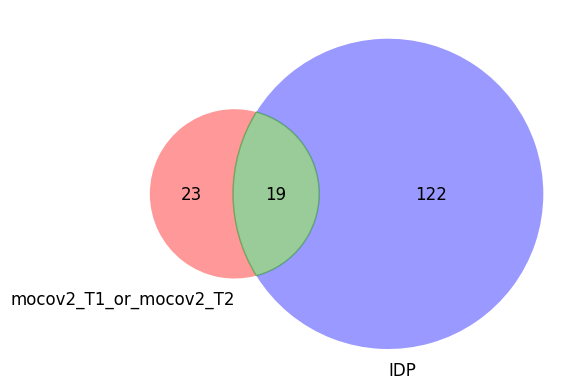

In [8]:
# this is an example of using the above code to draw the venn diagram of loci from 2 GWAS.
df_vit = pd.read_table("/data484_4/txia2/gwas_practice/fuma_result/vit_t1_fixed/GenomicRiskLoci.txt")
#df_T1_CNN = pd.read_table("/data4012/sislam3/playyard/MRI_UKB/POST_GWAS/data/AE/Revision2/minP/T1_model_128minP/GenomicRiskLoci.txt")
df2_T1_CNN = pd.read_table("/data484_1/kmohammed2/jackie_brainimaging/T1_128_UKBB_no_eval/FUMA/GenomicRiskLoci.txt")
df_CNN = pd.read_table("/data484_4/txia2/klush_loci_table_genomic_risk_loci.txt")
#df_IDP = pd.read_table("/data4012/sislam3/playyard/MRI_UKB/POST_GWAS/data/AE/Revision2/minP/IDP_Thres_1437/GenomicRiskLoci.txt")
df_IDP = pd.read_table("/data484_2/kmohammed2/xie_big40_minP/xie_big40_FUMA/GenomicRiskLoci.txt")
df_vit_samia = pd.read_table("/data484_4/txia2/gwas_practice/fuma_result/samia_vit/GenomicRiskLoci220.txt")
df_vit_single_gpu = pd.read_table("/data484_4/txia2/gwas_practice/fuma_result/vit_single_gpu/GenomicRiskLoci.txt")
df_vit_posembed = pd.read_table("/data484_4/txia2/gwas_practice/fuma_result/vit_posembed/GenomicRiskLoci.txt")
df_vit_posembed_smallerpatch = pd.read_table("/data484_4/txia2/gwas_practice/fuma_result/vit_posembed_smallerpatch/GenomicRiskLoci.txt")
df_vit_posembed_ssimloss = pd.read_table("/data484_4/txia2/gwas_practice/fuma_result/vit_posembed_ssimloss/GenomicRiskLoci.txt")
df_vit_posembed_attnpool = pd.read_table("/data484_4/txia2/gwas_practice/fuma_result/vit_posembed_attnpool/GenomicRiskLoci.txt")
df_vit_mae1 = pd.read_table("/data484_4/txia2/gwas_practice/fuma_result/vit_mae_replicate1/GenomicRiskLoci.txt")
df_vit_mae = pd.read_table("/data484_4/txia2/gwas_practice/fuma_result/vit_mae/GenomicRiskLoci.txt")
df_mocov2_205 = pd.read_table("/data484_4/txia2/gwas_practice/fuma_result/mocov2_205/GenomicRiskLoci.txt")
df_mocov2_219 = pd.read_table("/data484_4/txia2/gwas_practice/fuma_result/mocov2_219/GenomicRiskLoci.txt")
df_mocov2_t2 = pd.read_table("/data484_4/txia2/gwas_practice/fuma_result/mocov2_t2/GenomicRiskLoci.txt")
df_partial_fit_5std = pd.read_table("/data484_4/txia2/gwas_practice/fuma_result/mocov2_partial_fit_5std/GenomicRiskLoci.txt")
df_t2_5std = pd.read_table("/data484_4/txia2/gwas_practice/fuma_result/mocov2_t2_5std/GenomicRiskLoci.txt")
df_vit_t2 = pd.read_table("/data484_4/txia2/gwas_practice/fuma_result/vit_t2_fixed/GenomicRiskLoci.txt")
df_intersect_mocov2 = pd.read_table("/data484_4/txia2/mocov2/venn_overlap_loci/overlap_mocov2_T1_and_mocov2_T2.txt")
df_intersect_vit = pd.read_table("/data484_4/txia2/mocov2/venn_overlap_loci/overlap_vit_T1_and_vit_T2.txt")
df_union_mocov2 = pd.read_table("/data484_4/txia2/mocov2/venn_overlap_loci/union_mocov2_T1_and_mocov2_T2_merged.txt")
df_union_vit = pd.read_table("/data484_4/txia2/mocov2/venn_overlap_loci/union_vit_T1_and_vit_T2_merged.txt")
df_vit_crossattn_t1 = pd.read_table("/data484_4/txia2/gwas_practice/fuma_result/vit_crossattn_t1/GenomicRiskLoci.txt")
df_vit_crossattn_t2 = pd.read_table("/data484_4/txia2/gwas_practice/fuma_result/vit_crossattn_t2/GenomicRiskLoci.txt")
df_intersect_vit_crossattn = pd.read_table("/data484_4/txia2/mocov2/venn_overlap_loci/overlap_vit_crossattn_T1_and_vit_crossattn_T2.txt")
df_filtered_mocov2 = pd.read_table("/data484_4/txia2/mocov2/venn_overlap_loci/overlap_only_mocov2_T1_or_mocov2_T2.txt")


df_vit['SOURCE'] = 'vit_T1'
df_vit_t2['SOURCE'] = 'vit_T2'
#df_T1_CNN['SOURCE'] = 'CNN'
df_CNN['SOURCE'] = 'CNN'
df_IDP['SOURCE'] = "IDP"
df_mocov2_205['SOURCE'] = 'mocov2_205'
df_mocov2_219['SOURCE'] = 'mocov2_T1'
df_mocov2_t2['SOURCE'] = 'mocov2_T2'
df_vit_mae1['SOURCE'] = 'vit_mae'
df_partial_fit_5std['SOURCE'] = 'mocov2_T1'
df_t2_5std['SOURCE'] = 'mocov2_T2'
df_union_mocov2['SOURCE'] = 'mocov2_T1_or_mocov2_T2'
df_union_vit['SOURCE'] = 'vit_T1_or_vit_T2'
df_intersect_mocov2['SOURCE'] = 'mocov2_T1_and_mocov2_T2'
df_intersect_vit['SOURCE'] = 'vit_T1_and_vit_T2'
df_vit_crossattn_t1['SOURCE'] = 'vit_crossattn_T1'
df_vit_crossattn_t2['SOURCE'] = 'vit_crossattn_T2'
df_intersect_vit_crossattn['SOURCE'] = 'vit_crossattn_T1_and_vit_crossattn_T2'
df_filtered_mocov2['SOURCE'] = 'mocov2_vit_cnn'


trees = build_loci_tree([df_union_mocov2,df_IDP])

# Plot and save overlap loci to files
overlap_loci = venn_plot(trees, ['mocov2_T1_or_mocov2_T2', 'IDP'], 
                         output_dir='/data484_4/txia2/mocov2/venn_overlap_loci')
plt.gcf().subplots_adjust(left=0.1)

# Alternative: Get overlap loci as dictionary without saving files
# overlap_loci = extract_overlap_loci(trees, ['mocov2_T1', 'mocov2_T2','vit_T1','vit_T2'])